In [17]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
import pandas as pd
import plotly.express as px
import numpy as np
import plotly.graph_objects as go
import shap

/Users/maxi/miniconda3/envs/EML/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



# Load preprocessed California Housing Dataset

In [37]:
data = pd.read_parquet("../data/california_housing_prices.parquet")
X = data.drop(columns="HousePrice")
y = data["HousePrice"]

## Split train/ test data in 0.75:0.25 ratio

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(
    f"Train data rows: {len(X_train)} \n" 
    f"Test data rows: {len(X_test)}"
)

X_train.head()

Train data rows: 14736 
Test data rows: 4912


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
4081,34.62,52.0,4.953271,1.121495,1127.0,3.510903,34.12,-118.21
1511,50.50,32.0,6.213873,0.982659,486.0,2.809249,37.90,-122.08
8270,60.20,19.0,5.368794,1.049645,361.0,2.560284,33.87,-118.37
3942,41.15,28.0,5.455064,1.068474,1790.0,2.553495,34.19,-118.61
10155,23.95,25.0,4.798722,1.146965,891.0,1.423323,33.61,-117.71


## Train Boosted Tree model and make predictions on test data

In [41]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Evaluate model using set of performance metrics and compare to linear model

Compared to the linear regression model, the tree-based model achieves substantially better performance across all evaluation metrics. 

The MAE decreases from 38.89 to 18.99, meaning that the average prediction error is reduced by more than half. 
Similarly, the MAPE decreases from 31.01% to 17.28%, indicating that the tree model's predictions are considerably closer to the actual house values on average. 
The RMSE also decreases from 64.11 to 42.14, suggesting that the tree model produces fewer and/or smaller large prediction errors. 

Finally, the $R^2$ score increases from 0.5673 to 0.8131, meaning that the tree model explains approximately 81.0% of the variance in house prices compared to only 56.7% for the linear model. 

Overall, the substantial improvement across all metrics demonstrates that the tree-based model is better able to capture the non-linear relationships and interactions between the features and house prices that cannot be represented by the linear regression model.





In [43]:
mae = median_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(
    f"MAE:  {mae:.4f} \n"
    f"MAPE: {mape:.4f} \n" 
    f"RMSE: {rmse:.4f} \n"
    f"R²:   {r2:.4f}"
)

MAE:  18.9935 
MAPE: 0.1728 
RMSE: 42.1397 
R²:   0.8131


The following plot illustrates the magnitude of the prediction errors by comparing the actual and predicted house prices. The dashed line represents perfect predictions, where the predicted price is equal to the actual price. Therefore, predictions closer to this line correspond to smaller absolute errors, while points further away indicate larger errors. It can be observed that the model generally performs better for lower- and medium-priced houses, whereas its predictions become increasingly inaccurate for higher-priced houses. This suggests that the boosted tree model struggles to capture the factors associated with more expensive properties and therefore tends to underestimate or otherwise poorly predict house prices at the upper end of the distribution.

However, the tree-based model still achieves superior performance compared to the linear model. This is also reflected in the error plot, where the predictions are substantially less scattered around the ideal prediction line than those of the linear model, indicating that the tree-based model produces more accurate and consistent predictions.

In [44]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
})

fig = px.scatter(
    results,
    x="Actual",
    y="Predicted",
    title="Actual vs. Predicted House Prices",
    labels={
        "Actual": "Actual Price ($1,000)",
        "Predicted": "Predicted Price ($1,000)"
    },
)

# perfect prediction line
min_val = min(results["Actual"].min(), results["Predicted"].min())
max_val = max(results["Actual"].max(), results["Predicted"].max())

fig.add_shape(
    type="line",
    x0=min_val,
    y0=min_val,
    x1=max_val,
    y1=max_val,
    line=dict(dash="dash")
)

fig.update_layout(
    xaxis=dict(
        range=[0, 500],
        type="linear",
    ),
    yaxis=dict(
        range=[0, 500],
        type="linear",
    ),
)

fig.show()

# SHAP Values

Since tree-based models do not directly expose coefficients, there is no equivalent set of model coefficients that can be used to assess individual feature contributions. Therefore, SHAP provides a suitable approach for quantifying the contribution of each feature to the model's predictions.

Forcing SHAP to use `ExactExplainer` results in a computation time of approximately 3 minutes and 56 seconds. In contrast, allowing SHAP's `Explainer` class to automatically select the most appropriate algorithm results in the use of `TreeExplainer`, reducing the computation time to approximately 1 minute and 40 seconds. Since the objective at this stage is to compare the feature contributions between the linear and tree-based models, we use `ExactExplainer` for both models to ensure that the SHAP values are computed using the same model-agnostic method and are therefore directly comparable.

In [24]:
X_background = X_train.sample(n=100, random_state=42)
explainer = shap.ExactExplainer(model.predict, X_background)
shap_values = explainer(X_test)

ExactExplainer explainer: 4913it [03:56, 19.38it/s]                          


## SHAP value plots

To evaluate the real-world contribution of each feature to predicted house prices, we will analyze visualizations derived from the calculated SHAP values. A detailed mathematical breakdown of SHAP value calculations and the expected baseline model output, E[f(x)], can be found in the accompanying `shap_computation.ipynb` notebook.

### Bar Plot

Latitude, longitude, and median income are again identified as the primary drivers of the model's predictions. However, compared to the linear model, longitude and median income have a smaller relative contribution to the final predictions. Average occupation is the fourth most important feature for the tree-based model, whereas it was the least important feature in the linear model. Population is also considerably more influential for the tree-based model, with a contribution approximately 7.7 times larger than in the linear model. Despite this increase, its overall contribution remains negligible compared to the most influential features.


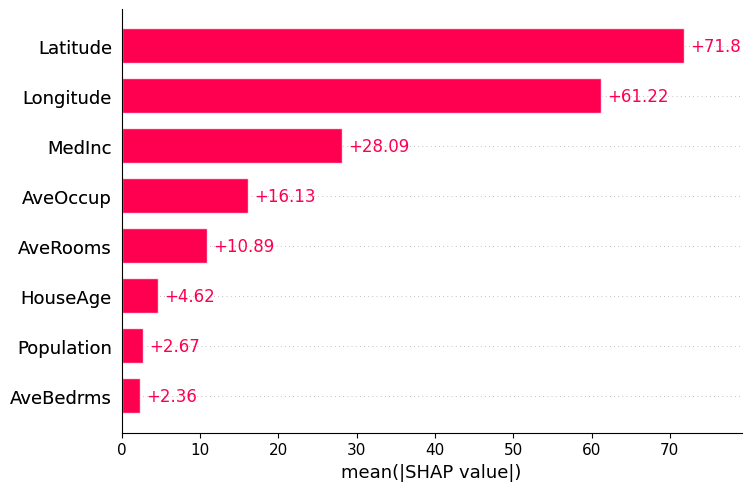

In [46]:
shap.plots.bar(shap_values)

### Individual Sample Plots

For the same sample used in the linear model, the feature contributions change considerably under the tree-based model. Longitude now has a positive SHAP value of +33.51, compared to −50.15 in the linear model, meaning that it increases the predicted house value rather than decreasing it. Median income has a SHAP value of +25.79, approximately half of its contribution in the linear model. Average occupation emerges as a new important contributor, with a SHAP value of +19.31. In contrast, average rooms, which previously increased the prediction in the linear model, now decreases it, with a SHAP value of -5.58.


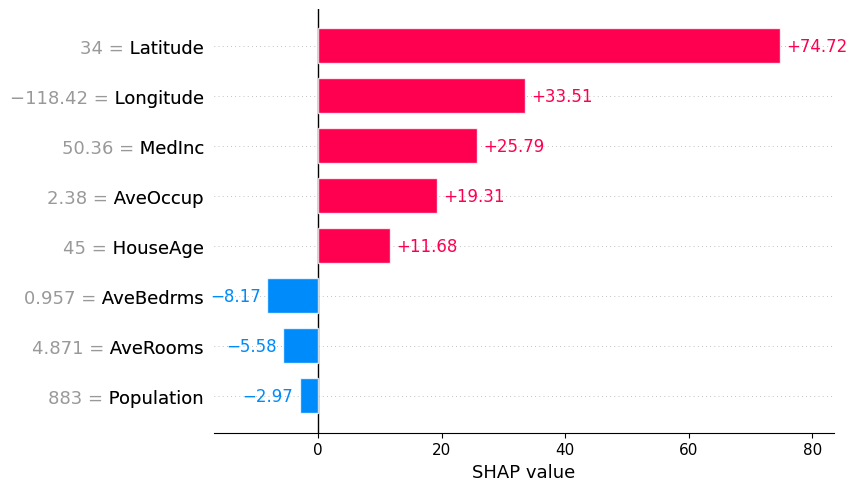

In [47]:
shap.plots.bar(shap_values[0])

The tree-based model produces a considerably more accurate prediction for this sample than the linear model, making its feature contributions more informative for explaining the observed house value. The tree-based model predicts $340,656, which is only $10,856 above the true value of $329,800, whereas the linear model predicts $277,656, underestimating the true value by $52,144. Consequently, the SHAP contributions of the tree-based model provide a more representative explanation of the factors underlying its prediction for this sample. This example also highlights how the two models can assign substantially different contributions to the same features, reflecting the tree model's ability to capture non-linear relationships and feature interactions that the linear model cannot represent.


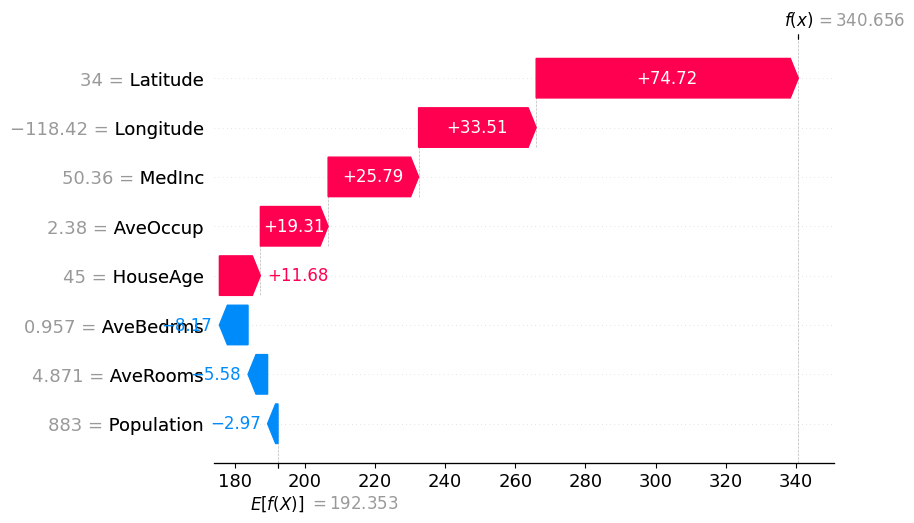

In [48]:
shap.plots.waterfall(shap_values[0])

### Global Feature Importance

Here, `Latitude` and `Longitude` are by far the most influential features, displaying a wide spread of SHAP values (ranging roughly from -200 to +200) with complex, non-monotonic color distributions that capture non-linear spatial regions. In contrast, the linear model severely restricts geographic influence to a narrower range (-200 to +100) and forces a strict, monotonic split where low values drive positive impacts and high values drive negative impacts.

The linear model suffers heavily from collinearity between `AveRooms` and `AveBedrms`. High values of `AveBedrms` push SHAP values strongly positive (up to +500), while high values of `AveRooms` push them strongly negative (down to -500), resulting in extreme, opposing SHAP values for highly correlated traits. The tree model handles these relationships far better, keeping SHAP contributions bounded smoothly between -100 and +100.

`AveOccup` acts as a moderately important feature in the tree model, but its impact vanishes almost completely at the bottom of the linear model, further highlighting the tree model's superior ability to extract non-linear interactions without falling prey to collinear feature inflation.

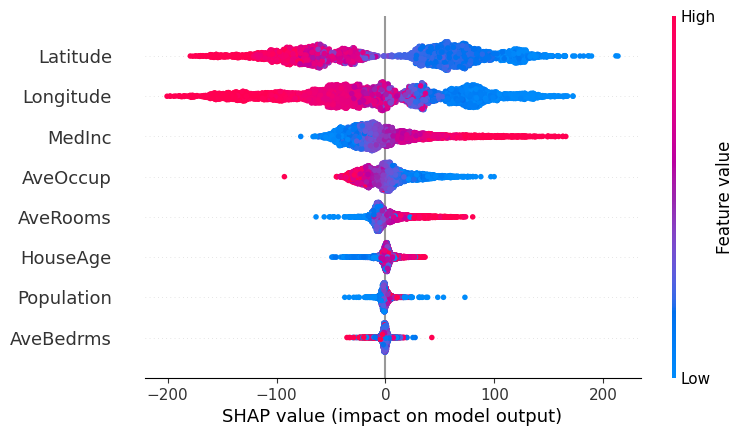

In [29]:
shap.plots.beeswarm(shap_values)

### SHAP Dependence Plot

The linear model enforces a perfectly strict, negative linear relationship where each additional room continuously decreases the prediction, driving SHAP values down to an extreme -500 for high values of `AveRooms`. Conversely, the tree model captures a non-linear relationship: SHAP values initially rise sharply as `AveRooms` increases up to around 6–8, after which the effect plateaus and levels off around +40 to +60.

The tree model automatically isolates a strong interaction with `AveBedrms`, showing that higher `AveBedrms` (red points) shift the SHAP value upward for a given room count. The linear model shows no meaningful interaction effect, keeping all data points aligned on a single straight line.

Extreme outliers (`AveRooms` > 30) cause massive negative extrapolation in the linear model, whereas the tree model smoothly bounds the impact of outliers to prevent absurdly large predictions.

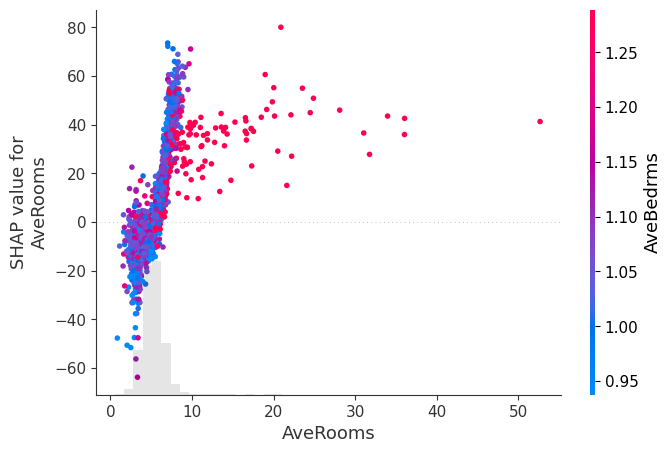

In [50]:
shap.plots.scatter(shap_values[:, "AveRooms"], color=shap_values[:, "AveBedrms"])

# Conclusion

Not only does the boosted tree model achieve substantially better prediction accuracy, as demonstrated by the set of performance metrics, but its improved ability to capture non-linear relationships and feature interactions also leads to substantially different SHAP explanations compared to the linear model.

It was shown that feature contributions can differ significantly between the tree-based and linear models, reflecting the fundamentally different relationships learned by the two approaches. Since SHAP explains the model rather than the underlying data-generating process, the quality and predictive performance of the model must always be considered when interpreting its feature contributions. In this case, the substantially lower prediction errors of the tree-based model make its explanations more representative of the model's predictions for the observed samples.

Additionally, the analysis demonstrates that individual feature contributions are highly dependent on the model used. Features that increase a prediction in the linear model can decrease it in the tree model, while previously unimportant features can become significant once non-linear relationships and interactions are taken into account. This highlights the importance of considering model choice when interpreting feature importance and demonstrates that SHAP should be used to understand a model's learned behavior rather than to infer causal relationships from the data.

Hence, we can conclude with a reasonable degree of confidence that geographic location and median income are the primary factors contributing to the model's predictions of housing prices in California.
